# <center><font color='green'>Desafío 5 -  Prediciendo los precios de las casas</font></center>

1. Analizar la calidad de datos, para lo que debes cargarlos y realizar un proceso
exhaustivo de limpieza para eliminar valores faltantes, duplicados y atípicos que
puedan afectar la calidad del modelo, si los hay.

In [17]:
# Importamos las bibliotecas necesarías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Creamos el dataframe usando 'pd.read_excel()'.
df= pd.read_excel('house_data.xlsx')

# Mostramos el dataframe creado.
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [2]:
# Vista general del dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  int64  
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [3]:
# Calidad de los datos.
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

#### Observaciones:
No se encontraron nulos, ni datos faltantes tampoco duplicados en los datos.

2. Realizar un análisis descriptivo de las variables para entender la distribución de los
datos y detectar posibles relaciones entre las características y los precios. En esto
debes incluir un análisis de correlaciones entre las variables principalmente con el
precio de las casas, comenta acerca de las variables con mayor correlación, ¿tienen
sentido?

In [6]:
# Estadísticas descriptivas generales.
display(df.describe())

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [11]:
# Análisis de Correlación.
# Calculamos la correlación de todas las numéricas con la columna 'price'.
correlaciones = df.select_dtypes(include=[np.number]).corr()['price'].sort_values(ascending=False)

print("\n--- Correlación con el Precio ---")
print(correlaciones)


--- Correlación con el Precio ---
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64


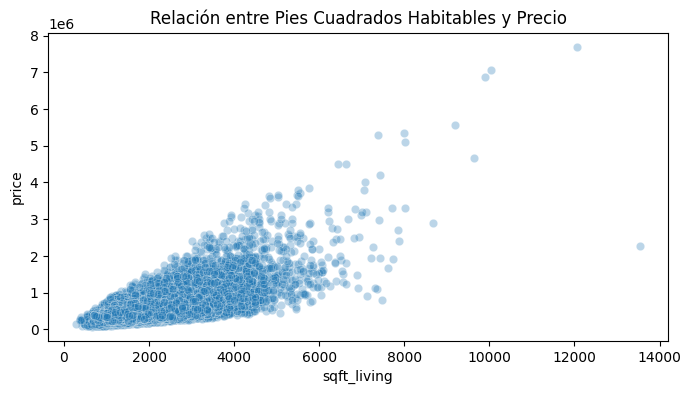

In [10]:
# Visualización: Sqft_living vs Price.
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.3)
plt.title('Relación entre Pies Cuadrados Habitables y Precio')
plt.show()

#### Concluciones: 
- Las variables con mayor sentido son:
 1. sqft_living (0.70): Es la más fuerte. Más metros cuadrados, mayor valor.
 2. grade (0.66): Es la segunda más fuerte. Indica que la calidad del material y el diseño son fundamentales para el precio.
 3. sqft_above (0.60) y bathrooms (0.52): Refuerzan que el tamaño y la comodidad afectan directamente el precio de una casa.
 4. sqft_lot (tamaño del terreno) tiene una correlación muy baja (0.08). Esto tiene sentido, ya que, en zonas urbanas un terreno gigante en las afueras puede valer menos que un departamento pequeño en el centro de la ciudad.
- Análisis de gráfico: se observa una Relación Lineal Positiva, a medida que aumentan los pies cuadrados (sqft_living), el precio tiende a subir. Esto confirma que la variable es un excelente predictor para el modelo. La "nube" de puntos tiene una forma ascendente, lo cual valida el uso de una regresión lineal.

3. Divide los datos en conjuntos de entrenamiento y prueba de manera aleatoria o
estratificada, dejando un 33% para test, luego de eso aplica alguna técnica de
transformación de datos, como normalización o estandarización, para asegurar que
las variables estén en una escala comparable.
(hint: Recuerda que en la estandarización o normalización de los datos el
fit.transform solo se aplica a los datos de train, mientras que a los datos de test se
les aplica solo el transform).

In [13]:
# Primero vamos a eliminar las columnas 'id' y 'date' porque no resultan variables predictoras para este análisis.
df_modelo = df.drop(columns=['id', 'date'])

In [14]:
# Basandonos en el análisis del gráfico, filtramos los valores extremos (para que no afecten a los modelos sensibles).
# Ajustamos a menos de 13,000 sqft y precios menores a 6 millones.(ELiminamos outliers)
df_filtrado = df_modelo[(df_modelo['sqft_living'] < 13000) & (df_modelo['price'] < 6000000)]

print(f"Registros eliminados (outliers): {len(df_modelo) - len(df_filtrado)}")
print(f"Nuevo tamaño del dataset: {df_filtrado.shape}")

Registros eliminados (outliers): 4
Nuevo tamaño del dataset: (21609, 19)


In [15]:
# Dividimos los datos.
# Definimos X (características) e y (objetivo).
X = df_filtrado.drop(columns=['price'])
y = df_filtrado['price']

# Dividimos con el 33% para test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [16]:
# Estandarizamos.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Variables utilizadas: {X.columns.tolist()}")
print(f"Muestras de entrenamiento: {X_train_scaled.shape[0]}")
print(f"Muestras de prueba: {X_test_scaled.shape[0]}")

Variables utilizadas: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
Muestras de entrenamiento: 14478
Muestras de prueba: 7131


4. Implementar modelos de regresión lineal con regularización, como Ridge, Lasso y
Elastic Net con ajuste de hiper parámetros, según tabla sugerida, debes construir
además un modelo de árboles de regresión para capturar relaciones no lineales y complejas entre las variables predictoras y el precio de las casas, finalmente genera
un cuadro comparativo con modelos y métricas.

In [18]:
# Definimos los parámetros para la búsqueda.
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
elastic_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
tree_params = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [19]:
# Inicializamos los modelos y almacenamiento de resultados.
modelos = {
    'Lasso': GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5),
    'Ridge': GridSearchCV(Ridge(), ridge_params, cv=5),
    'Elastic Net': GridSearchCV(ElasticNet(max_iter=10000), elastic_params, cv=5),
    'Árbol de Regresión': GridSearchCV(DecisionTreeRegressor(random_state=42), tree_params, cv=5)
}

resultados = []

In [22]:
# Entrenamiento y Evaluación.
print("Entrenando modelos con GridSearchCV...")

for nombre, grid in modelos.items():
    # Entrenamos el modelo con los datos escalados del punto anterior.
    grid.fit(X_train_scaled, y_train)
    
    # Obtenemos el mejor modelo encontrado.
    best_model = grid.best_estimator_
    
    # Realizamos las predicciones.
    y_pred = best_model.predict(X_test_scaled)
    
    # Calcular métricas
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Guardamos los resultados.
    resultados.append({
        'Modelo': nombre,
        'Mejor Parametro': grid.best_params_,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

Entrenando modelos con GridSearchCV...


C:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.317e+13, tolerance: 1.453e+11
  model = cd_fast.enet_coordinate_descent(
C:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.269e+13, tolerance: 1.438e+11
  model = cd_fast.enet_coordinate_descent(
C:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

In [23]:
# Generamos el Cuadro Comparativo.
df_comparativo = pd.DataFrame(resultados)
print("\n--- Cuadro Comparativo de Modelos ---")
display(df_comparativo)


--- Cuadro Comparativo de Modelos ---


,Modelo,Mejor Parametro,MAE,RMSE,R2 Score
0,Lasso,{'alpha': 10},124682.233480,204195.330948,0.692077
1,Ridge,{'alpha': 10},124663.042891,204197.209829,0.692072
2,Elastic Net,"{'alpha': 0.01, 'l1_ratio': 0.5}",124518.911141,204215.268837,0.692017
3,Árbol de Regresión,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",88799.461542,155937.667450,0.820422


#### Conclusión:
El Árbol de Regresión fue el modelo más preciso, con un R² de 0.82 y un error promedio de  88,799 (MAE). 
Superó significativamente a los modelos lineales (Ridge, Lasso y Elastic Net), que solo alcanzaron un R² de 0.69 y un error de 124,000. Esto indica que el precio de las casas en esta base de datos se explica mejor mediante relaciones complejas y no lineales.

5. Elige uno de los modelos de regresión lineal con regularización implementados en el
punto anterior y gráfica cómo varían sus hiperparámetros durante el ajuste,
mostrando también cómo afectan el rendimiento del modelo.

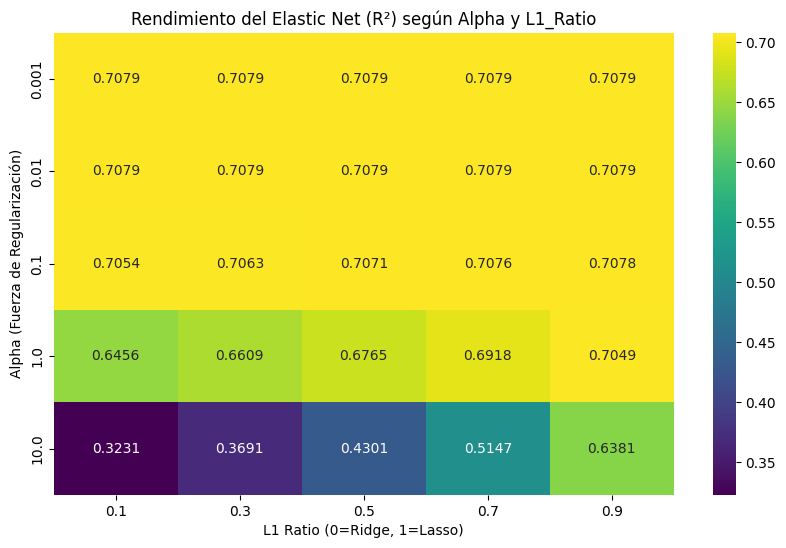

In [24]:
# Extraemos los resultados del GridSearchCV de Elastic Net,
# 'modelos' es el diccionario donde guardamos los GridSearch en el punto anterior.
grid_en = modelos['Elastic Net']
results_df = pd.DataFrame(grid_en.cv_results_)

# Pivotamos la tabla para tener alpha en un eje y l1_ratio en el otro.
# Usamos el 'mean_test_score' que representa el R2 promedio durante el entrenamiento.
pivoted_results = results_df.pivot(index='param_alpha', 
                                   columns='param_l1_ratio', 
                                   values='mean_test_score')

# Graficamos.
plt.figure(figsize=(10, 6))
sns.heatmap(pivoted_results, annot=True, cmap='viridis', fmt=".4f")
plt.title('Rendimiento del Elastic Net (R²) según Alpha y L1_Ratio')
plt.xlabel('L1 Ratio (0=Ridge, 1=Lasso)')
plt.ylabel('Alpha (Fuerza de Regularización)')
plt.show()

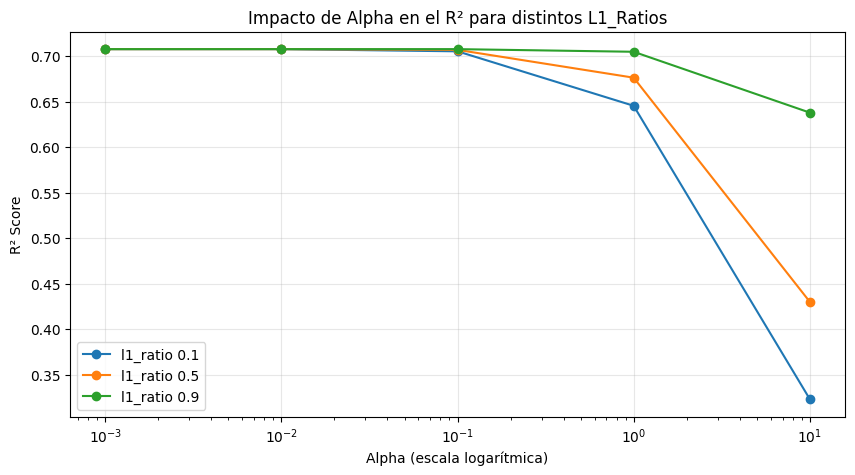

In [25]:
# Gráficamos la Evolución del error según Alpha.
plt.figure(figsize=(10, 5))
for r in [0.1, 0.5, 0.9]:
    subset = results_df[results_df['param_l1_ratio'] == r]
    plt.plot(subset['param_alpha'], subset['mean_test_score'], marker='o', label=f'l1_ratio {r}')

plt.xscale('log') # Usamos escala logarítmica porque alpha varía en potencias de 10.
plt.title('Impacto de Alpha en el R² para distintos L1_Ratios')
plt.xlabel('Alpha (escala logarítmica)')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Conclusiones:
- Durante el ajuste del modelo Elastic Net, se observa que el rendimiento (R²) es óptimo con valores de Alpha bajos (0.001 a 0.01), alcanzando su punto máximo en 0.01. 
- Al incrementar el Alpha hacia 10, el modelo sufre una pérdida severa de precisión, lo que indica que una regularización demasiado fuerte penaliza excesivamente los coeficientes, impidiendo que el modelo capture la varianza de los datos. 
- El mejor equilibrio se encontró con un l1_ratio de 0.5, combinando equitativamente las ventajas de las penalizaciones L1 y L2.

6. Utilizar métricas de evaluación de regresión, como el Error Cuadrático Medio (MSE),
el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²), para medir el
rendimiento del modelo, realizar cuadro comparativo indicado en el punto 4, finaliza
con una breve conclusión de a los resultados obtenidos.

In [27]:
# Agregaremos el MSE que es la columna que nos falta.
# MSE (es el RMSE al cuadrado).
df_comparativo['MSE'] = df_comparativo['RMSE']**2  

# Reordenamos las columnas para una presentación más clara.
cuadro_final = df_comparativo[['Modelo', 'Mejor Parametro', 'MAE', 'MSE', 'R2 Score']]

print("--- CUADRO COMPARATIVO ---")
display(cuadro_final)

--- CUADRO COMPARATIVO ---


,Modelo,Mejor Parametro,MAE,MSE,R2 Score
0,Lasso,{'alpha': 10},124682.233480,4.169573e+10,0.692077
1,Ridge,{'alpha': 10},124663.042891,4.169650e+10,0.692072
2,Elastic Net,"{'alpha': 0.01, 'l1_ratio': 0.5}",124518.911141,4.170388e+10,0.692017
3,Árbol de Regresión,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",88799.461542,2.431656e+10,0.820422


#### Conclusión:
El proceso de modelado permitió comparar técnicas de regresión lineal regularizada (Lasso, Ridge y Elastic Net) frente a métodos basados en estructuras jerárquicas (Árboles de Regresión).
- Rendimiento de Modelos Lineales: Los modelos con regularización obtuvieron resultados similares, con un R² aproximado de 0.69.
- Árbol de Regresión: Este modelo fue el que tuvo mejores resultados, con un R² de 0.82. Al no estar restringido por la linealidad, pudo capturar mejor la complejidad de los datos (como la interacción entre ubicación, calidad de construcción y metros cuadrados), reduciendo el error promedio (MAE) de 124,000 a 88,799.
- Métricas de Error: El MSE y MAE disminuyeron significativamente en el Árbol de Regresión, lo que indica una mayor precisión en las predicciones de los precios de las viviendas.

Para este problema específico, se recomienda el uso del Árbol de Regresión (con los hiperparámetros ajustados: max_depth: 10, min_samples_leaf: 2), ya que ofrece un equilibrio óptimo entre precisión y generalización, superando a los métodos lineales.